# Quick Start Tutorial

Before you begin: 
- Ensure you are in a conda environment built from the `environment.yml` file. It has all the required dependencies and their versions for running the code.
- Read through the documents I wrote here: https://dev-undergrad.dev/tags/nasa/ so you can understand how the code *works* before trying to *work* with it yourself


### Contents: 
1. Eigenspectra Simulations 
2. Simulating EDMR
3. Performing Least-Squares Optimizations
4. Sweeping over parameters 

## Eigenspectra Simulations 
---

INFO:root: Starting eigensimulation for 'zeeman_hyperfine_zfs_exchange'
100%|███████████████████████████████████████████████████████████████████| 200/200 [00:06<00:00, 30.48it/s]


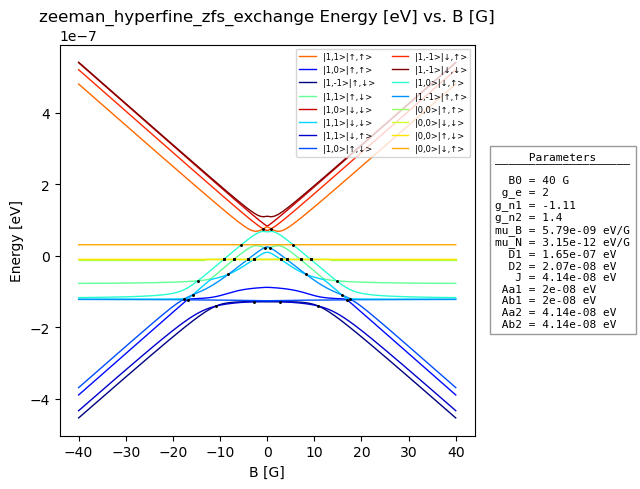

INFO:root: 'full_spin_hamiltonian' simulation saved to 
 quick_start_files/full_spin_hamiltonian_sweep.png.



In [1]:
from edmr_sim.eigenspectra.energy_simulation import sweep 
from pathlib import Path

# run the simulation 
sweep(
    method_name = "zeeman_hyperfine_zfs_exchange", # Full Spin Hamiltonian
    b_sweep     = (-40, 40, 200),                  # B range (-40, 40), # steps 200 
    verbose     = False,                           # suppress excess output  
    outdir      = Path("./quick_start_files/"),    # directory to place output .png 
)

To see the allowed names (different hamiltonian combinations) for the `method_name=` argument, run 

In [2]:
from edmr_sim.eigenspectra.energy_simulation import allowed_method_names
allowed_method_names() 

dict_keys(['zeeman_only', 'hyperfine_only', 'zfs_only', 'exchange_only', 'zeeman_hyperfine', 'zeeman_zfs', 'zeeman_exchange', 'hyperfine_zfs', 'hyperfine_exchange', 'zfs_exchange', 'zeeman_hyperfine_zfs', 'zeeman_hyperfine_exchange', 'zeeman_zfs_exchange', 'hyperfine_zfs_exchange', 'zeeman_hyperfine_zfs_exchange'])


To change the Hamiltonian parameters for the simulation, you have to load the `.yaml` file, edit the dictionary, and write back. 

In [3]:
import yaml 
from pathlib import Path 
from edmr_sim.eigenspectra.energy_simulation import PARAMETER_FILE 


# read the parameter file 
with PARAMETER_FILE.open("r") as f:
    config = yaml.safe_load(f)


print(config) # the hamiltonian parameters 

{'exchange': {'J': 4.14e-08}, 'hyperfine': {'A1_iso': 2e-08, 'A2_iso': 4.14e-08}, 'zeeman': {'B0': 40.0, 'g_e': 2.002319, 'g_n1': -1.110104, 'g_n2': 1.404738, 'mu_B': 5.7883818e-09, 'mu_N': 3.1524512e-12}, 'zfs': {'D1': 1.65e-07, 'D2': 2.07e-08}}


In [4]:
# changing hyperfine strength of nucleus 1 
config["hyperfine"]["A1_iso"] = 2e-08 # eV

with PARAMETER_FILE.open("w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

INFO:root: Starting eigensimulation for 'zeeman_hyperfine_zfs_exchange'
100%|███████████████████████████████████████████████████████████████████| 200/200 [00:06<00:00, 30.45it/s]


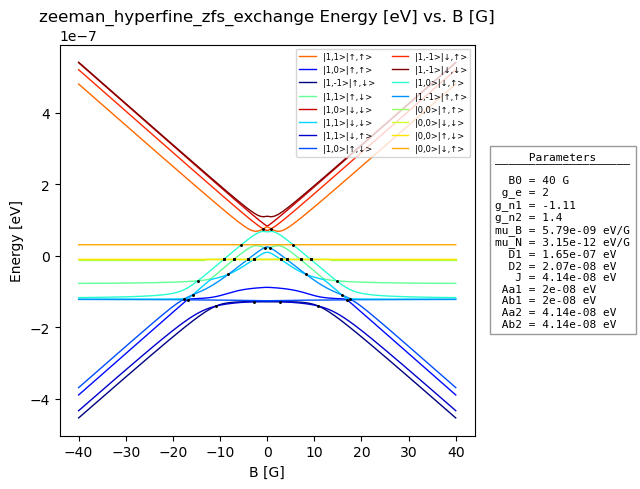

INFO:root: 'full_spin_hamiltonian' simulation saved to 
 quick_start_files/full_spin_hamiltonian_sweep.png.



In [5]:
# Now running simulation again 
sweep(
    method_name = "zeeman_hyperfine_zfs_exchange", # Full Spin Hamiltonian
    b_sweep     = (-40, 40, 200), 
    verbose     = False,                           # suppress excess output  
    outdir      = Path("./quick_start_files/"), 
)

The hyperfine parameters Aa1 and Ab1 have changed from 4.14e-8 to 2e-8. The highest-energy (reddest) state now has a small "divot" at 0G. This concludes the eigenspectra tutorial, you can generate similar images for any combination of the four sub-hamiltonians -- Zeeman, Hyperfine, ZFS, Exchange -- by changing the `method_name=` argument shown above. 

## EDMR Simulations 
--- 

### Single Sweep

We'll first plot simulated data against a real experimental spectra. 

***Parameters for the simulation are by default taken from `fitting/main/utils/params.yaml`*** 

Rendering EDMR LSQ Fit with 100 steps.

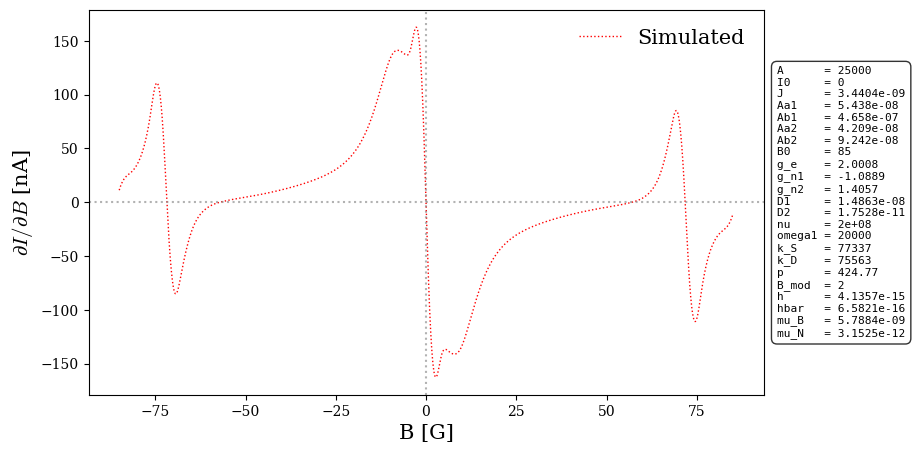

INFO:edmr_sim.fitting.main.least_squares: fig::EDMR_LeastSquares_no_mod.png 



Took 0.2576160430908203 seconds.

In [6]:
from edmr_sim.fitting.main.least_squares import EDMRLeastSquaresPlotter, _build_least_squares_fitter 
from edmr_sim.fitting.main.utils.csv_to_npz import npz_to_arrays 

# Real Data -- an .npz file with two columns "B" and "I" from a real experiment 
# This function converts into two numpy ndarrays 
raw_B_data, raw_I_data = npz_to_arrays("3V-2G-200MHz.npz")

plotter = EDMRLeastSquaresPlotter(
    raw_B_data=raw_B_data, 
    raw_I_data=raw_I_data, 
    #parameters= (default .utils/params.yaml), 
    n_points_interp=100, 
    init_check=True, 
    plot_raw=False,   # Overplots the raw data -- for just seeing the simulated spectra, set to False 
    verbose=True, 
    modulate=True     # Activate lock-in modulation 
)
                      # `n_points_interp`
                      # To simulate you just need roughly 1 point per Gauss 
                      # It later interpolates the discrete points back into 
                      # the same length as `raw_B_data`
        
                      # `init_check` 
                      # Performs an initial check for solving the SLE ensuring 
                      # everything is going correctly (recommended, only takes ~0.3s) 
                      # i.e. Verifying Matrix Hermicity, Positivty, etc. 

#  ** NOTE ** 
# I only explain the most important parameter descriptions here  
# There are more default parameters and their descriptions in the documentation. 


simulated_B, simulated_I = plotter.plot_fitted_EDMR_spectra()

Rendering EDMR LSQ Fit with 100 steps.

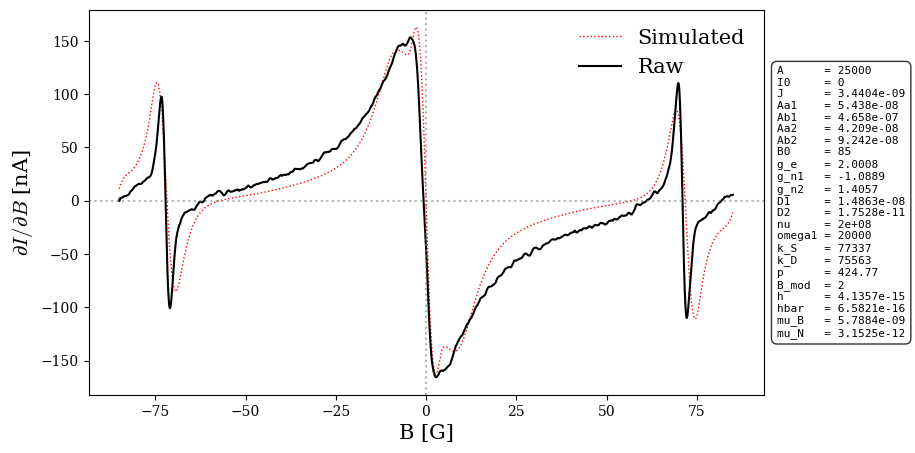

INFO:edmr_sim.fitting.main.least_squares: fig::EDMR_LeastSquares_no_mod.png 



Took 0.1799321174621582 seconds.

In [7]:
# overplotting the Raw Data
plotter.plot_raw = True 
simulated_I, simulated_B = plotter.plot_fitted_EDMR_spectra()

## Performing Least-Squares Optimization 

***Note, the parameter space is super degenerate and HEAVILY depends on the initial conditions you set.***

In [8]:
# The initial parameter guesses are by default the parameters in the yaml file. 


fitter = _build_least_squares_fitter(
    raw_B_data=raw_B_data,  # data to fit against 
    raw_I_data=raw_I_data,  # data to fit against 
    n_points_interp=100,
    init_check=False,       # trust the SLE solve is correct, save a little time (not recommended though, you should keep it True) 
)

result = fitter.fit()

WARNING: not performing preliminary checks. This is highly recommended and only takes ~0.1s per iteration.

INFO:edmr_sim.fitting.main.least_squares: ~/ Pickle Saving Active /~
INFO:edmr_sim.fitting.main.least_squares: This will consume ~130us every full iteration.
INFO:edmr_sim.fitting.main.least_squares: /Users/devaldeliwala/nasa/edmr_sim/fitting/main/utils/lsq_param.pickle


Least-Squares started at 2025‑08‑08 14:32:53

--------------------------------------------

Ansatz Parameters:

...

       4              9         1.5908e+09      6.33e+06       7.82e+03       1.28e+11    


INFO:edmr_sim.fitting.main.least_squares:~/ Parameter pickle saved. ~/


       5             17         1.5908e+09      0.00e+00       0.00e+00       1.28e+11    
`xtol` termination condition is satisfied.
Function evaluations 17, initial cost 2.1054e+09, final cost 1.5908e+09, first-order optimality 1.28e+11.


Least-Squares ended at 2025-08-08 14:33:06

Time Elapsed: 13.171966s

Alright, let's try to parse everything that happened. 

- We set `init_check=False`, so we got a `WARNING`.
- The Ansatz parameters (initial guesses) are shown and were taken from the `.yaml` file.
- We see `Pickle Saving Active` -- this is default, and saves every parameter optimization to a `.pickle` file so you don't have to rerun.

We can change the fitting configuration via three dataclasses: 

In [9]:
from edmr_sim.fitting.main.least_squares import LeastSquaresMultiThread, LeastSquaresParameters, LeastSquaresPickling

# Multithreading parameters (by default 1 core) 
print(LeastSquaresMultiThread())
print("")
# Ansatz parameters (by default takes from the params.yaml file and wide bounds
print(LeastSquaresParameters())
print("") 

# Pickling parameters 
print(LeastSquaresPickling())

LeastSquaresMultiThread(n_jobs=1, blocks_per_core=1)

LeastSquaresParameters(default_parameters=True, ansatz_parameters=None, lower_bound={'A': 0.0001, 'I0': 0.0, 'J': 1e-09, 'Aa1': 1e-09, 'Ab1': 1e-09, 'Aa2': 1e-09, 'Ab2': 1e-09, 'D1': 1e-09, 'D2': 1e-12, 'B0': -50.0, 'g_e': 2.0, 'g_n1': -1.2, 'g_n2': 1.2, 'nu': 190000000.0, 'omega1': 1000.0, 'k_S': 100.0, 'k_D': 1000.0, 'p': 10.0, 'B_mod': 0.1, 'h': 4.135667662e-15, 'hbar': 6.58211e-16, 'mu_B': 5.7883818e-09, 'mu_N': 3.1524512e-12}, upper_bound={'A': 10000000.0, 'I0': 20000.0, 'J': 5e-07, 'Aa1': 5e-07, 'Ab1': 5e-07, 'Aa2': 5e-07, 'Ab2': 5e-07, 'D1': 1e-07, 'D2': 1e-10, 'B0': 50.0, 'g_e': 2.01, 'g_n1': -1.0, 'g_n2': 1.6, 'nu': 210000000.0, 'omega1': 10000000.0, 'k_S': 100000000.0, 'k_D': 1000000000.0, 'p': 1000000.0, 'B_mod': 10.0, 'h': 4.135667662e-15, 'hbar': 6.58211e-16, 'mu_B': 5.7883818e-09, 'mu_N': 3.1524512e-12})

LeastSquaresPickling(save_pickle=True, pickle_dirs=PosixPath('/Users/devaldeliwala/nasa/edmr_sim/fitting/main/utils

In [10]:
# Let's rerun the fitting but with Multithreading active. 
fitter = _build_least_squares_fitter(
    raw_B_data=raw_B_data,  
    raw_I_data=raw_I_data, 
    n_points_interp=100,
    init_check=False,  
    multithread_params=LeastSquaresMultiThread(n_jobs=2, blocks_per_core=2), # 2 cores
    show_progress=True # display progress bar 
)

result = fitter.fit()

WARNING: not performing preliminary checks. This is highly recommended and only takes ~0.1s per iteration.

INFO:edmr_sim.fitting.main.least_squares: ~/ Pickle Saving Active /~
INFO:edmr_sim.fitting.main.least_squares: This will consume ~130us every full iteration.
INFO:edmr_sim.fitting.main.least_squares: /Users/devaldeliwala/nasa/edmr_sim/fitting/main/utils/lsq_param.pickle


Least-Squares started at 2025‑08‑08 14:33:06

--------------------------------------------

Ansatz Parameters:

...

       4              9         1.5908e+09      6.33e+06       7.82e+03       1.28e+11    


100%|███████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  5.91it/s]
INFO:edmr_sim.fitting.main.least_squares:~/ Parameter pickle saved. ~/


       5             17         1.5908e+09      0.00e+00       0.00e+00       1.28e+11    
`xtol` termination condition is satisfied.
Function evaluations 17, initial cost 2.1054e+09, final cost 1.5908e+09, first-order optimality 1.28e+11.


Least-Squares ended at 2025-08-08 14:34:28

Time Elapsed: 81.160439s

You can see using 2 cores over 1 actually took 6 times longer. This is because all the SLE solves are primarily matrix operations, which are already numpy BLAS optimized (and usually spawn their own mini threads). Hence, using 1 core is optimal. The final optimized parameters are in the `.pickle` file. This concludes the least squares fitting tutorial.

## Sweeping over Parameters 
---

The purpose of this is to be able to see how simulated EDMR spectra change *as a function* of any combination of the Hamiltonian Parameters. For example, increasing the RF frequency `nu` obviously shifts the Zeeman resonances further out -- but does it do anything else? we have to do a fine sweep to find out. 

The following code shows how to perform *many* and visualize them together. It allows you to define any number of parameters and their sweep ranges, and simulates the spectra over *every combination of every parameter* using an itertools chain. 

***Note: This is computationally intensive for more than two parameters, still possible though.***

In [11]:
from edmr_sim.sweeping.main.multi_dimensional_sweep import SweepConfig, Sweep
from pathlib import Path

""" 
This code allows you to do a multi-parameter dimension sweep, 
i.e. simulate spectra over every combination of every parameter value. 

The output file gets stored as an .nc (netCDF) file xarray -- 
I'll show how to parse this file after. 

Say we want to sweep across the RF frequency (nu) and the Rabi Frequency (omega1) 
- nu ranging from 190MHz to 210MHz in 30 steps 
- omega1 ranging from 200kHz to 400kHz in 20 steps. 
    - 600 simulations in total! 
    
- set the B range to be -100G to 100G consistently 

"""

# configuration 
cfg = SweepConfig(
    B_range          = (-100, 100),
    parameter_keys   = [
        "nu", "omega1" 
    ],
    parameter_ranges = [
        (1.90e8, 2.1e8, 30), # nu 
        (2.0e5, 4.0e5, 20),   # omega1 
    ],
    n_points_interp  = 100,
    n_final_points   = 4096,   # the # of final interpolated points 
    save_plot        = False,  # to save plots in ./media/ for every nu and omega (discouraged, takes lot of space if many steps) 
    init_check       = False,  
    disable_warning  = True,
    out_directory    = Path("./quick_start_files/netCDF"),  # directory to place output .nc database file 
    out_filename     = "sweep.nc"                           # name of output .nc file 
)

In [12]:
sweep = Sweep(cfg)
data  = sweep.render()

[INFO]::   nu   :: (1.900e+08, 2.100e+08, 30)
[INFO]:: omega1 :: (2.000e+05, 4.000e+05, 20)


100%|███████████████████████████████████████████████████████████████████| 600/600 [01:04<00:00,  9.24it/s]

[INFO] Saved NetCDF to quick_start_files/netCDF/sweep.nc


Took about 30 seconds for 600 simulations, about 0.05 seconds per. Let's parse the output file so we can work with the data. I've written a helper file to do this. 

Running the second time is much faster because of caching. 

Let's first see all the nu and omega values that were measured: 

In [13]:
from edmr_sim.sweeping.main.parse_cdf import RenderNetCDF, ParseNetCDF 

parser = ParseNetCDF(
    cdf_filename=cfg.out_filename, 
    cdf_directory=cfg.out_directory, 
)

print("Parameters Swept Over:", parser.load_dims)
print("Values Measured:", parser.load_param_dict)

Parameters Swept Over: ('nu', 'omega1')
Values Measured: {'nu': array([1.90000000e+08, 1.90689655e+08, 1.91379310e+08, 1.92068966e+08,
       1.92758621e+08, 1.93448276e+08, 1.94137931e+08, 1.94827586e+08,
       1.95517241e+08, 1.96206897e+08, 1.96896552e+08, 1.97586207e+08,
       1.98275862e+08, 1.98965517e+08, 1.99655172e+08, 2.00344828e+08,
       2.01034483e+08, 2.01724138e+08, 2.02413793e+08, 2.03103448e+08,
       2.03793103e+08, 2.04482759e+08, 2.05172414e+08, 2.05862069e+08,
       2.06551724e+08, 2.07241379e+08, 2.07931034e+08, 2.08620690e+08,
       2.09310345e+08, 2.10000000e+08]), 'omega1': array([200000.        , 210526.31578947, 221052.63157895, 231578.94736842,
       242105.26315789, 252631.57894737, 263157.89473684, 273684.21052632,
       284210.52631579, 294736.84210526, 305263.15789474, 315789.47368421,
       326315.78947368, 336842.10526316, 347368.42105263, 357894.73684211,
       368421.05263158, 378947.36842105, 389473.68421053, 400000.        ])}


Say we want to get the simulated current for the run that had 

- nu closest to 201MHz
- omega1 closest to 330kHZ
(both are within their sweep ranges)

In [14]:
renderer = RenderNetCDF(
    cdf_filename=cfg.out_filename, 
    cdf_directory=cfg.out_directory, 
)

slice = renderer.slice(
    parameter_values={
        "nu": 201.0e5,    # 201MHz 
        "omega1": 330.0e3 # 330kHZ 
    } 
)
print(slice)

This returns a `ParameterSlice` object that has the following attributes:  

In [15]:
slice.B    # B array 

array([-100.        ,  -99.95115995,  -99.9023199 , ...,   99.9023199 ,
         99.95115995,  100.        ], shape=(4096,))

In [16]:
slice.dI   # lock-in derivative current

array([ 7.51149409,  7.85575039,  8.19071998, ..., -8.19071998,
       -7.85575039, -7.51149409], shape=(4096,))

In [17]:
slice.I    # integrated current

array([ 0.00000000e+00,  3.75268485e-01,  7.67123684e-01, ...,
        7.67123681e-01,  3.75268483e-01, -2.08797224e-09], shape=(4096,))

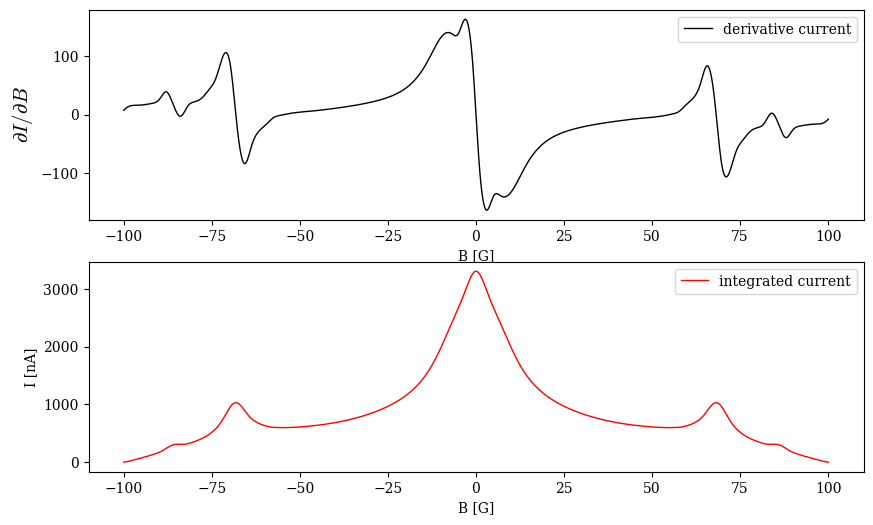

In [18]:
import matplotlib.pyplot as plt 

figure, axis = plt.subplots(2, 1,  figsize=(10, 6)) 

axis[0].plot(slice.B, slice.dI, c='k', linewidth=1, label='derivative current')
axis[1].plot(slice.B, slice.I,  c='r', linewidth=1, label='integrated current') 

axis[0].set_ylabel(r"$\partial I /\partial B$", fontsize=15) 
axis[1].set_ylabel("I [nA]")

for ax in axis: 
    ax.set_xlabel("B [G]", fontsize=10)
    ax.legend()

**RECOMMENDATION** 

Because the lock-in EDMR spectra is antisymmetric and the integrated current is symmetric about the y-axis, I highly recommended just sweeping across positive B (e.g. 0-100G) 
Then you can just add the negative side -- this way you can reduce compilation time (or do a finer B sweep in the same time). 

#### 3D Plots
---

Alright, now we know how to do multi-dimensional sweeps. Now let's try to visualize how EDMR spectra evolve as a function of a *single* parameter. 

We'll focus on `nu`. 

In [19]:
from edmr_sim.sweeping.main.plot_cdf import PlotSingle3DSweep

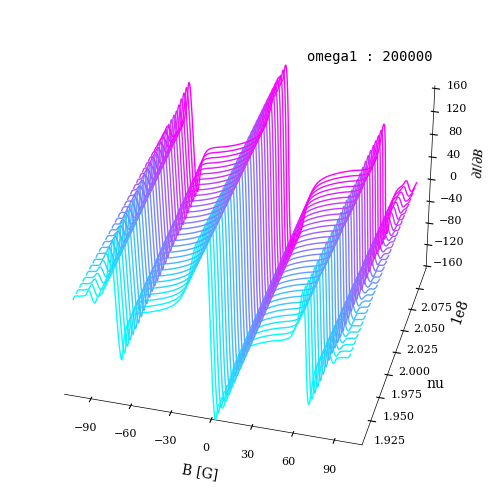

[INFO]:: 3D Surface Plot Saved:: quick_start_files/nu_lockin_surf.png


<Figure size 640x480 with 0 Axes>

In [20]:
single_plot = PlotSingle3DSweep(
        param_name="nu", 
        cdf_filename=cfg.out_filename,
        cdf_directory=cfg.out_directory, 
        out_directory=Path("./quick_start_files/")
)

fig, ax = single_plot.current_plot(current_type='lockin', plot_full=True, figsize=(5, 5))

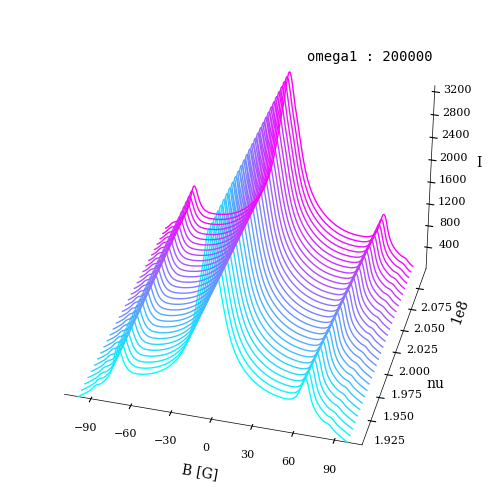

[INFO]:: 3D Surface Plot Saved:: quick_start_files/nu_integrated_surf.png


<Figure size 640x480 with 0 Axes>

In [21]:
fig, ax = single_plot.current_plot(current_type='integrated', plot_full=True, figsize=(5, 5))

The `plot_full` argument determines whether to only plot the positive B-half of the spectra or whether to plot the full neg-to-pos EDMR spectra. 
Again, when running these sweeps, choose a positive-only B-range and do a finer-sweep. Then when plotting you can set `plot_full=True` to render the full spectra.

This sweep wasn't fine enough to see any unique features. What I do is run the multi-dimensional sweep but with only one parameter:  

In [22]:
cfg = SweepConfig(
    B_range          = (0, 100), # only the right half 
    parameter_keys   = [
        "nu", 
    ],
    parameter_ranges = [
        (1.90e8, 2.1e8, 1000), # 1000 STEPS! 

    ],
    n_points_interp  = 100,
    n_final_points   = 4096,   
    save_plot        = False,  
    init_check       = False,  
    disable_warning  = True,
    out_directory    = Path("./quick_start_files/netCDF"),  
    out_filename     = "sweep_finer.nc"                        
)
#sweep = Sweep(cfg)
#data  = sweep.render()

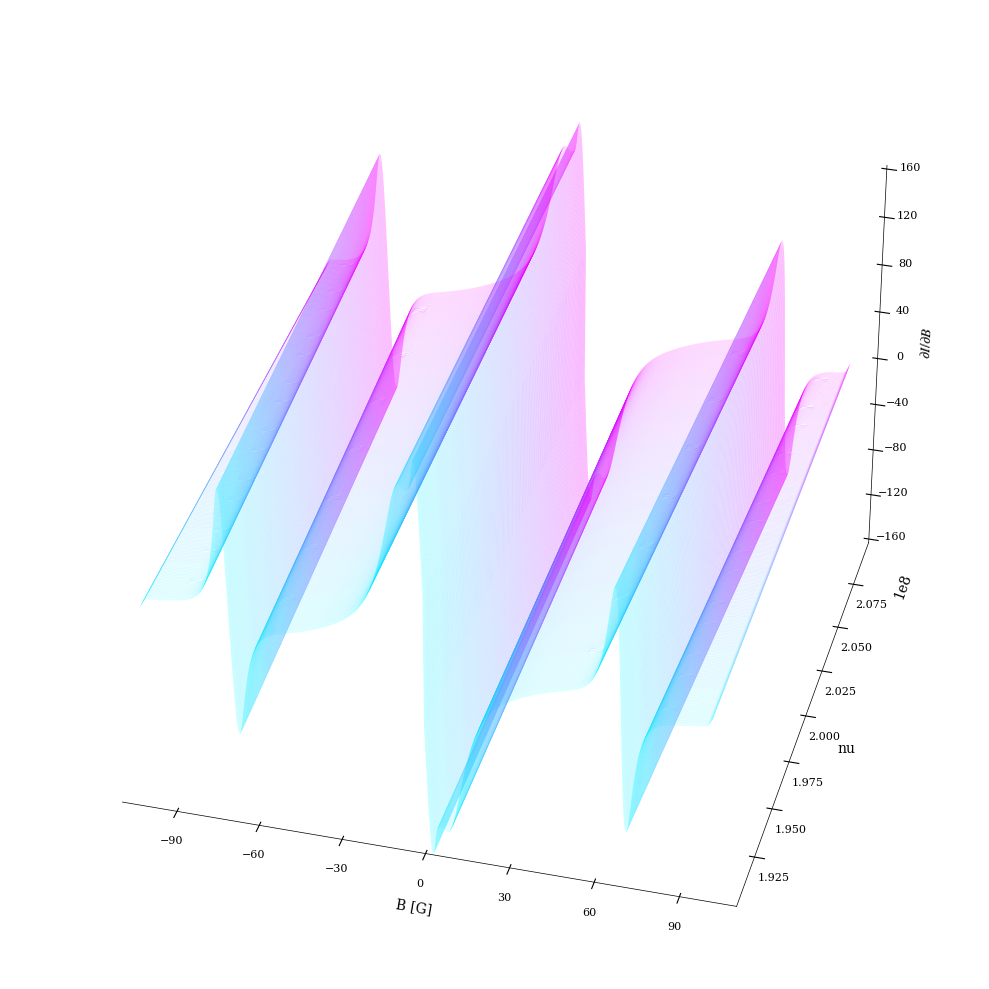

[INFO]:: 3D Surface Plot Saved:: quick_start_files/nu_lockin_surf.png


<Figure size 640x480 with 0 Axes>

In [23]:
single_plot = PlotSingle3DSweep(
        param_name="nu", 
        cdf_filename=cfg.out_filename,
        cdf_directory=cfg.out_directory, 
        out_directory=Path("./quick_start_files/")
)

fig, ax = single_plot.current_plot(current_type='lockin', plot_full=True, figsize=(10, 10)) # still plots full spectra 

If you look closely you can see some features at ±55G and ±80G, but the resolution is also reduced in a notebook output. 

If you open the actual file (whos path is shown in the output), and zoom in around 55G and 80G you should see some wiggles every now and then across nu.

This concludes the quick-start tutorial. 